## Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Loading and Viewing the Dataset

In [3]:
# creating a variable to store the absolute .csv file path for the full Deep4Chem dataset
d4c_path = r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_chemprop/Deep4Chem_chemprop/d4c_ext_coef_all_data.csv'

# reading in the dataset as stored in the path variable
d4c = pd.read_csv(d4c_path)

# printing the index and heading of each column in the dataset
for i, col in enumerate(d4c.columns):
    print(i, repr(col))

# viewing the shape (no. entries) and title of columns contained by the data
print('Shape:', d4c.shape)
print('\nColumns:')
for col in d4c.columns:
    print(repr(col))

# checking for missing values within the dataset
print('\nMissing values:')
print(d4c.isnull().sum())

0 'Chromophore'
1 'Solvent'
2 'Absorption max (nm)'
3 'log(e/mol-1 dm3 cm-1)'
Shape: (8032, 4)

Columns:
'Chromophore'
'Solvent'
'Absorption max (nm)'
'log(e/mol-1 dm3 cm-1)'

Missing values:
Chromophore              0
Solvent                  0
Absorption max (nm)      0
log(e/mol-1 dm3 cm-1)    0
dtype: int64


#### Comments:
8,032 datapoints in Deep4Chem dataset representing ~3.8k unique chromophores

No missing values in dataset => handy for later analysis

## **HPC-Based Replication**

## Reproducing Figure 2 - Prediction Analysis

In [4]:
# loading test Deep4Chem dataset and modern Chemprop ensemble/individual predictions obtained utilising the HPC cluster
test = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/d4c_test.csv')
modern_preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/chemprop_v2/modern_d4c_predicting/ensemble_preds_individual.csv')

In [5]:
# specifying columns within the ensemble/individual prediction outputs file which are related to wavelength and log(molar extinction coefficient),
# respectively
wavelength_cols = [c for c in modern_preds.columns if 'Absorption max (nm)_model_' in c]
log_cols = [c for c in modern_preds.columns if 'log(e/mol-1 dm3 cm-1)_model_' in c]

# converting string values to numeric (float) values for both predicted target properties' columns
modern_preds['Absorption max (nm)'] = (modern_preds[wavelength_cols].astype(float).mean(axis=1))
modern_preds['log(e/mol-1 dm3 cm-1)'] = (modern_preds[log_cols].astype(float).mean(axis=1))

In [6]:
# creating lists to store evaluation metrics for predicted wavelength values
modern_wavelength_rmse = []
modern_wavelength_mae = []

# creating lists to store evaluation metrics for predicted log(molar extinction coefficient) values
modern_log_mec_rmse = []
modern_log_mec_mae = []

# iterating through prediction files
for i in range(10):
    # splitting predicted values for both targets into separate variables
    modern_pred_wavelength = modern_preds[f'Absorption max (nm)_model_{i}']
    modern_pred_log_mec = modern_preds[f'log(e/mol-1 dm3 cm-1)_model_{i}']

    # removing rows where prediction failed and keeping valid rows only
    valid_preds = (modern_preds['Absorption max (nm)'].notna() & modern_preds['log(e/mol-1 dm3 cm-1)'].notna())
    
    # splitting valid true values for wavelength and log(molar extinction coefficient) into separate variables
    true_wavelength = test.loc[valid_preds, 'Absorption max (nm)']
    true_log_mec = test.loc[valid_preds, 'log(e/mol-1 dm3 cm-1)']
    
    # calculating evaluation metrics for wavelength into separate lists
    modern_wavelength_rmse.append(np.sqrt(mean_squared_error(true_wavelength, modern_pred_wavelength)))
    modern_wavelength_mae.append(mean_absolute_error(true_wavelength, modern_pred_wavelength))

    # calculating evaluation metrics for log(molar extinction coefficient) into separate lists
    modern_log_mec_rmse.append(np.sqrt(mean_squared_error(true_log_mec, modern_pred_log_mec)))
    modern_log_mec_mae.append(mean_absolute_error(true_log_mec, modern_pred_log_mec))

# calculating (ensemble) evaluation metrics for wavelength across all 10 models
ensemble_wavelength_rmse = np.sqrt(mean_squared_error(true_wavelength, modern_preds['Absorption max (nm)']))
ensemble_wavelength_mae = mean_absolute_error(true_wavelength, modern_preds['Absorption max (nm)'])

# calculating (ensemble) evaluation metrics for log(molar extinction coefficient) across all 10 models
ensemble_log_mec_rmse = np.sqrt(mean_squared_error(true_log_mec, modern_preds['log(e/mol-1 dm3 cm-1)']))
ensemble_log_mec_mae = mean_absolute_error(true_log_mec, modern_preds['log(e/mol-1 dm3 cm-1)'])

# calculating (ensemble) standard deviations for both wavelength error metrics across all models
ensemble_wavelength_rmse_sd = np.std(modern_wavelength_rmse)
ensemble_wavelength_mae_sd = np.std(modern_wavelength_mae)

# calculating (ensemble) standard deviations for both log(molar extinction coefficient) error metrics across all models
ensemble_log_mec_rmse_sd = np.std(modern_log_mec_rmse)
ensemble_log_mec_mae_sd = np.std(modern_log_mec_mae)

In [7]:
# printing evaluation metrics for both target properties
print('Modern D4C Wavelength RMSE:', ensemble_wavelength_rmse, '+/-', ensemble_wavelength_rmse_sd)
print('Modern D4C Wavelength MAE:', ensemble_wavelength_mae, '+/-', ensemble_wavelength_mae_sd)

print('\nModern D4C Log(molar extinction coefficient) RMSE:', ensemble_log_mec_rmse, '+/-', ensemble_log_mec_rmse_sd)
print('Modern D4C Log(molar extinction coefficient) MAE:', ensemble_log_mec_mae,'+/-', ensemble_log_mec_mae_sd)

Modern D4C Wavelength RMSE: 27.67525690761128 +/- 1.2686054948110803
Modern D4C Wavelength MAE: 18.39663226828558 +/- 1.070597542668602

Modern D4C Log(molar extinction coefficient) RMSE: 0.29710858986346556 +/- 0.008699183235263594
Modern D4C Log(molar extinction coefficient) MAE: 0.19048246088149587 +/- 0.006021721617763763


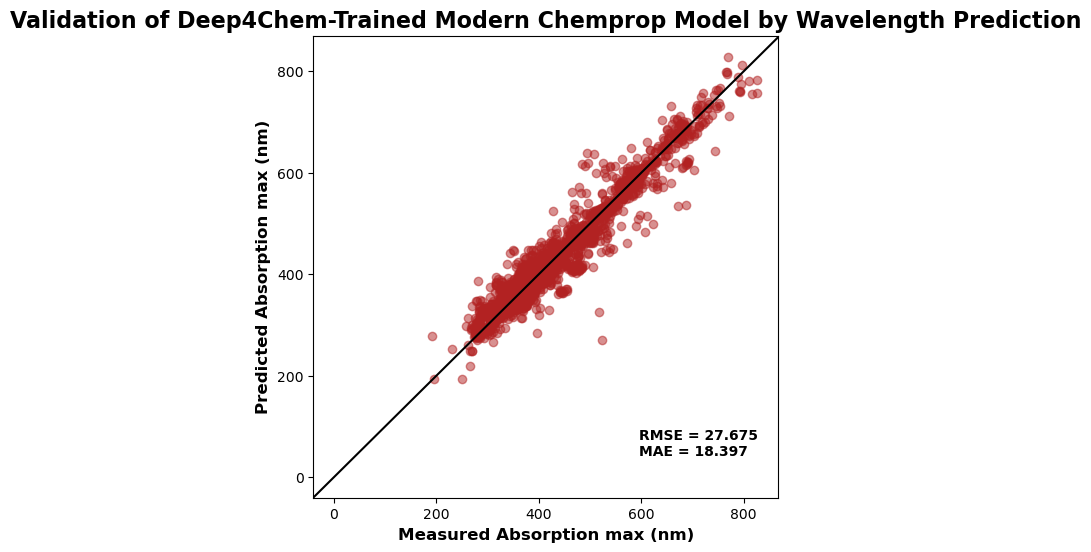

In [8]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(true_wavelength, modern_pred_wavelength, alpha=0.5, color='firebrick')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Deep4Chem-Trained Modern Chemprop Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained ensemble evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {ensemble_wavelength_rmse:.3f}\nMAE = {ensemble_wavelength_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

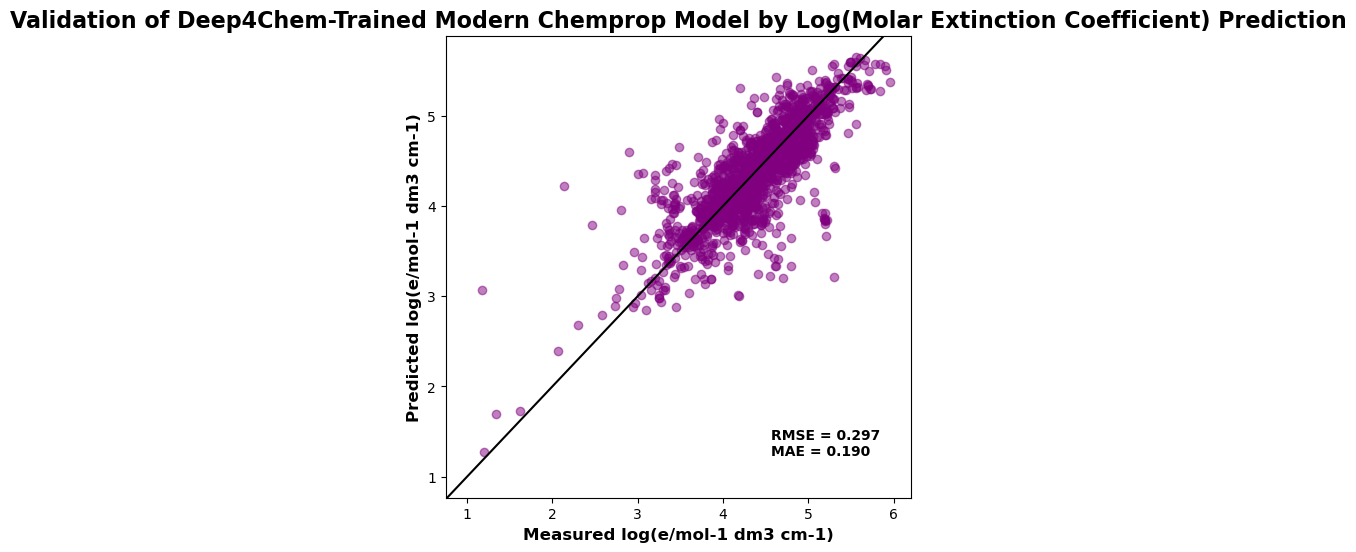

In [9]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(true_log_mec, modern_pred_log_mec, alpha=0.5, color='purple')

# adding ideal prediction line (r^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Deep4Chem-Trained Modern Chemprop Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained ensemble evaluation metric values (excluding SDs)
plt.text(0.70, 0.15, f'RMSE = {ensemble_log_mec_rmse:.3f}\nMAE = {ensemble_log_mec_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

### Comments:

Same process executed on the HPC returned slightly lower outputted metrics, exceeding the lower standard deviation bounds by the Google Colab experiments' results - reduction not as drastic as e.g. authors' errors vs. my Google Colab errors, will accept this as further general methodology validation and attribute output differences to environmental changes and inherent random chance between deep learning models

Simpler, shorter analysis workflow possible when specifying the ensemble predictions CSV should include individual model predictions during the prediction command

